---
title: "Fitting Large Datasets in Limited Memory"
description: "Manage TabPFN memory use with training subsampling, test-set chunking, and the API client."
cookbookTags:
  - performance
  - classification
  - api
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

# Fitting Large Datasets in Limited Memory

*Three levers for keeping a large dataset within a GPU's memory budget.*

A large training or test set can push TabPFN past the available GPU memory and trigger `CUDA out of memory`. Memory use is driven by two things, the size of the training context and the size of the test batch, and each one has a lever. We work through three techniques from the [OOM troubleshooting guide](https://docs.priorlabs.ai/troubleshooting/OOM-errors):

1. **Subsample** a large training set
2. **Chunk** a large test set
3. Offload entirely to the **API client**

Everything below runs on a single Colab **T4 (16 GB)**.

## Setup

*Install, import, and authenticate.*

In [1]:
!pip install -q tabpfn scikit-learn tabpfn-client matplotlib numpy torch

In [2]:
import gc
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier

from google.colab import userdata

print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

Device: Tesla T4


In [3]:
os.environ["TABPFN_TOKEN"] = userdata.get('TABPFN_TOKEN')

## Building a Large Dataset

*200,000 rows and 100 features.*

In [4]:
X, y = make_classification(
    n_samples=200000,
    n_features=100,
    n_informative=50,
    n_redundant=0,
    random_state=0,
    shuffle=False,
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)
print(f"train: {X_train.shape}  test: {X_test.shape}")

train: (140000, 100)  test: (60000, 100)


## Measuring Peak VRAM

*Reset the counter before each run, read the peak afterwards.*

We reset PyTorch's memory counter before each run, then read back the peak allocation afterwards.

In [5]:
PEAK_VRAM = {}

def reset_gpu():
    """Clear caches and reset the peak-memory counter before a run."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def record(label):
    """Store and print the peak VRAM since the last reset_gpu()."""
    if not torch.cuda.is_available():
        print(f"{label}: no GPU available")
        return
    torch.cuda.synchronize()
    gb = torch.cuda.max_memory_allocated() / 1024**3
    PEAK_VRAM[label] = gb
    print(f"{label}: peak VRAM = {gb:.2f} GB")

## Baseline: the Naive Fit

*The whole train and test set at once*

First the obvious thing: hand TabPFN the whole training set and the whole test set at once.

In [6]:
reset_gpu()
try:
    model = TabPFNClassifier(
        device="auto",
        ignore_pretraining_limits=True,
        n_estimators=1
    )
    model.fit(X_train, y_train)
    model.predict_proba(X_test)
    record("Naive Training")
except RuntimeError as e:
    if "out of memory" not in str(e).lower():
        raise
    PEAK_VRAM["Naive"] = float("nan")
    print("CUDA out of memory: the full 140k train + 60k test pass won't fit on a T4.")
    print("This is exactly the failure the techniques below avoid.")

Naive Training: peak VRAM = 3.56 GB


## Subsampling a Large Training Set

*`SUBSAMPLE_SAMPLES` caps how many rows each estimator attends over.*

Rather than attend over all 140,000 training rows, each estimator sees a balanced random subset. Set `SUBSAMPLE_SAMPLES`, then raise `n_estimators` so the ensemble still covers the data.

In [7]:
reset_gpu()
model = TabPFNClassifier(
    device="auto",
    ignore_pretraining_limits=True,
    n_estimators=10,
    inference_config={
        "SUBSAMPLE_SAMPLES": 20_000,
    },
)
model.fit(X_train, y_train)
model.predict_proba(X_test)
record("Subsample train")

Subsample train: peak VRAM = 1.58 GB


## Predicting a Large Test Set in Chunks

*Process the test rows in batches, not all at once.*

Feeding all 60,000 test rows at once spikes memory; instead we predict in chunks of 3,000 and stack the results. Same predictions, a fraction of the peak. This lever tackles the test side, independently of the training set.

In [8]:
model = TabPFNClassifier(
    device="auto",
    ignore_pretraining_limits=True,
    fit_mode="fit_with_cache",
    n_estimators=1,
)
model.fit(X_train, y_train)

reset_gpu()
model.predict_proba(X_test)
record("Naive Prediction")

reset_gpu()
predictions = []
CHUNK_SIZE = 3000
X_test_arr = np.asarray(X_test)

for i in range(0, len(X_test_arr), CHUNK_SIZE):
    chunk_preds = model.predict_proba(X_test_arr[i : i + CHUNK_SIZE])
    predictions.append(chunk_preds)

predictions = np.vstack(predictions)
record("Chunked Prediction")



Naive Prediction: peak VRAM = 3.36 GB
Chunked Prediction: peak VRAM = 2.70 GB


## The Story in One Chart

*Peak VRAM for each lever, against the T4 ceiling.*

Peak GPU VRAM for each approach. The naive run completed at 3.56 GB; subsampling and chunking reduced peak memory further, with all measured runs below the T4's 16 GB ceiling.

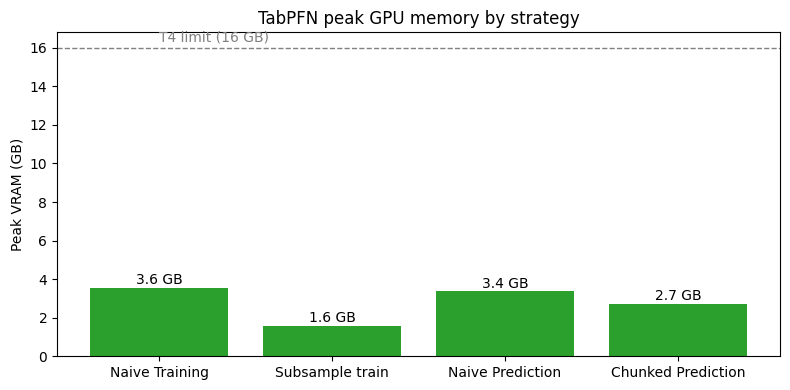

In [9]:
labels = list(PEAK_VRAM)
values = np.array([PEAK_VRAM[k] for k in labels])
oom = np.isnan(values)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, np.where(oom, 0, values),
              color=np.where(oom, "#d62728", "#2ca02c"))
ax.axhline(16, ls="--", color="gray", lw=1)
ax.text(0, 16.3, "T4 limit (16 GB)", color="gray")
ax.set_ylabel("Peak VRAM (GB)")
ax.set_title("TabPFN peak GPU memory by strategy")

for bar, v, is_oom in zip(bars, values, oom):
    text = "OOM" if is_oom else f"{v:.1f} GB"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2, text, ha="center")

plt.tight_layout()
plt.show()

## No GPU? Use the API Client

*Run the exact same model remotely, with zero local VRAM.*

If you do not have (or do not want to manage) a GPU, `tabpfn_client` runs the exact same model on Prior Labs' infrastructure. Local GPU VRAM use: zero.

In [10]:
from tabpfn_client import TabPFNClassifier

model = TabPFNClassifier()
model.fit(X_train, y_train)
predictions = model.predict_proba(X_test)

Found existing access token, reusing it for authentication.

00:02 Fitting... |

00:02 Fitting... Done!
00:00 Predicting... /

01:03 Predicting... Done!
